In [56]:
# Standard library imports
from pathlib import Path
from datetime import datetime
from typing import List, Union
import warnings
import numpy as np  

# Third-party imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
from torchinfo import summary
import matplotlib.pyplot as plt
from loguru import logger

import mlflow
import mlflow.pytorch

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

# Project-specific imports
from mads_datasets import DatasetFactoryProvider, DatasetType
from mltrainer.preprocessors import BasePreprocessor
from mltrainer import metrics, Trainer, TrainerSettings, ReportTypes

warnings.simplefilter("ignore", UserWarning)

In [2]:
fashionfactory = DatasetFactoryProvider.create_factory(DatasetType.FASHION)
batchsize = 64
preprocessor = BasePreprocessor()
streamers = fashionfactory.create_datastreamer(batchsize=batchsize, preprocessor=preprocessor)
train = streamers["train"]
valid = streamers["valid"]
trainstreamer = train.stream()
validstreamer = valid.stream()

2026-03-01 07:24:22.181 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /Users/stevenbontius/.cache/mads_datasets/fashionmnist
2026-03-01 07:24:22.182 | INFO     | mads_datasets.base:download_data:124 - File already exists at /Users/stevenbontius/.cache/mads_datasets/fashionmnist/fashionmnist.pt


In [3]:
x, y = next(iter(trainstreamer))

In [4]:
x.shape, y.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [5]:
torch.unique(y)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)

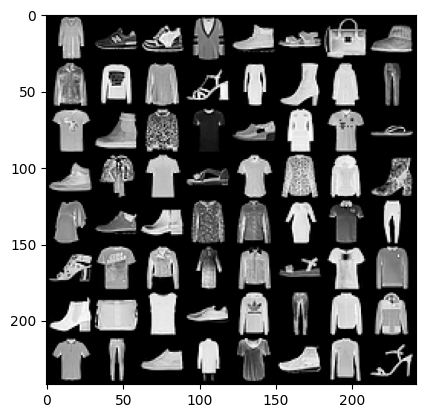

In [6]:
#create a grid of images
grid = make_grid(x, nrow=8)
plt.imshow(grid.permute(1, 2, 0))

In [7]:
# Create baseline model version 1
# Some code smell still present

class FashionBaseline(nn.Module):
    def __init__(self, 
                 conv_channels: List[int] = [16, 32],
                 fully_connected_dim: int = 256)-> None:
        """
        Base line model for the MNIST FASHION 28 x 28 dataset
        :param conv_channels: Output channels of each conv block
        :param fully_connected_dim: Number of neurons of the dense layer before feeding to classification
        """
        super().__init__()
        self.features: nn.ModuleList = nn.ModuleList()

        in_channels: int = 1 # Fashion MNIST is grayscale

        # Feature extractor block
        # CONV -> RELU -> MAX_POOL
        for out_channels in conv_channels:
            self.features.append(nn.Conv2d(in_channels=in_channels,
                                           out_channels=out_channels, 
                                           kernel_size=3,
                                           padding=1))
            self.features.append(nn.ReLU())
            self.features.append(nn.MaxPool2d(kernel_size=2,
                                              stride=2))
            in_channels = out_channels

        # Classifier block
        # Using lazy layer to get dimensions
        # 10 classification output
        self.classifier: nn.Sequential = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(fully_connected_dim),
            nn.ReLU(),
            nn.Linear(fully_connected_dim, 10)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Iterate trough the layers
        for layer in self.features:
            x = layer(x)
        
        # Classify
        return self.classifier(x)

In [8]:
# check hardware acceleration and choose device
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

# init model
model = FashionBaseline().to(device)

# get batch for init lazy layer
dummy_input, _ = next(iter(trainstreamer))

# get one image and move to device
dummy_input = dummy_input[0:1].to(device)

# init model no nograd to save memory
with torch.no_grad():
    model(dummy_input)

# print summary and check device

print(summary(model, input_data=dummy_input))
print(f"Model is loaded on: {next(model.parameters()).device}")

Using device: mps
Layer (type:depth-idx)                   Output Shape              Param #
FashionBaseline                          [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Conv2d: 2-1                       [1, 16, 28, 28]           160
│    └─ReLU: 2-2                         [1, 16, 28, 28]           --
│    └─MaxPool2d: 2-3                    [1, 16, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 32, 14, 14]           4,640
│    └─ReLU: 2-5                         [1, 32, 14, 14]           --
│    └─MaxPool2d: 2-6                    [1, 32, 7, 7]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 1568]                 --
│    └─Linear: 2-8                       [1, 256]                  401,664
│    └─ReLU: 2-9                         [1, 256]                  --
│    └─Linear: 2-10                      [1, 10]          

In [9]:
optimizer = optim.Adam
loss_fn = torch.nn.CrossEntropyLoss()
accuracy = metrics.Accuracy()

In [10]:
# sanity check
x, y = next(iter(trainstreamer))
yhat = model(x.to(device))
accuracy(y, yhat)


0.140625

In [11]:
log_dir = Path("modellog").resolve()
if not log_dir.exists():
    log_dir.mkdir(parents=True)

In [12]:
settings = TrainerSettings(
    epochs=3,
    metrics=[accuracy],
    logdir=log_dir,
    train_steps=len(train),
    valid_steps=len(valid),
    reporttypes=[ReportTypes.TOML],
)
settings

epochs: 3
metrics: [Accuracy]
logdir: /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/modellog
train_steps: 937
valid_steps: 156
reporttypes: [<ReportTypes.TOML: 'TOML'>]
optimizer_kwargs: {'lr': 0.001, 'weight_decay': 1e-05}
scheduler_kwargs: {'factor': 0.1, 'patience': 10}
earlystop_kwargs: {'save': False, 'verbose': True, 'patience': 10}

In [13]:
trainer = Trainer(
    model=model,
    settings=settings,
    loss_fn=loss_fn,
    optimizer=optimizer,
    traindataloader=trainstreamer,
    validdataloader=validstreamer,
    scheduler=optim.lr_scheduler.ReduceLROnPlateau,
    device=device,
    )

2026-03-01 07:24:22.631 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/modellog/20260301-072422
2026-03-01 07:24:22.640 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


In [14]:
trainer.loop()

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 937/937 [00:06<00:00, 152.74it/s]
2026-03-01 07:24:29.340 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.4957 test 0.3491 metric ['0.8746']
100%|██████████| 937/937 [00:05<00:00, 178.84it/s]
2026-03-01 07:24:34.879 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 0.3148 test 0.3085 metric ['0.8867']
100%|██████████| 937/937 [00:05<00:00, 184.70it/s]
2026-03-01 07:24:40.252 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 0.2676 test 0.2923 metric ['0.8918']
100%|██████████| 3/3 [00:17<00:00,  5.84s/it]


In [15]:
class FashionDynamicModel(nn.Module):
    def __init__(self,
                 dummy_input: torch.Tensor,
                 conv_channels: List = [16, 32],
                 fully_connected_dim: int = 128):
        super().__init__()

        self.features = nn.ModuleList()
        # Auto detect input channels
        in_channels = dummy_input.shape[1]

        # Build conv layers
        for out_channels in conv_channels:
            self.features.append(nn.Conv2d(in_channels=in_channels,
                                           out_channels=out_channels, 
                                           kernel_size=3,
                                           padding=1))
            self.features.append(nn.ReLU())
            self.features.append(nn.MaxPool2d(kernel_size=2,
                                              stride=2))
            in_channels = out_channels

        # Classifier block
        # Using lazy layer to get dimensions
        # 10 classification output
        self.classifier: nn.Sequential = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(fully_connected_dim),
            nn.ReLU(),
            nn.Linear(fully_connected_dim, 10)
        )

        # move to the device of the dummy_input
        device = dummy_input.device
        self.to(device=device)

        # Self init the lazy layer
        with torch.no_grad():
            self.forward(dummy_input)

        # Report which device is active
        logger.info(f"Model initialized and materialized on device: {device}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.features:
            x = layer(x)
        return self.classifier(x)

In [16]:
x, y = next(iter(trainstreamer))

In [17]:
init_tensor = x[0:1].to(device="mps")
dyn_model = FashionDynamicModel(init_tensor)

2026-03-01 07:24:40.312 | INFO     | __main__:__init__:42 - Model initialized and materialized on device: mps:0


In [18]:
summary(dyn_model, input_data=init_tensor)

Layer (type:depth-idx)                   Output Shape              Param #
FashionDynamicModel                      [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Conv2d: 2-1                       [1, 16, 28, 28]           160
│    └─ReLU: 2-2                         [1, 16, 28, 28]           --
│    └─MaxPool2d: 2-3                    [1, 16, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 32, 14, 14]           4,640
│    └─ReLU: 2-5                         [1, 32, 14, 14]           --
│    └─MaxPool2d: 2-6                    [1, 32, 7, 7]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 1568]                 --
│    └─Linear: 2-8                       [1, 128]                  200,832
│    └─ReLU: 2-9                         [1, 128]                  --
│    └─Linear: 2-10                      [1, 10]                   1,290
Tot

In [ ]:
# Setting up ML Flow
experiment_path = "fashion_test_bn"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(experiment_path)

modeldir = Path("models/rnn").resolve()
if not modeldir.exists():
    modeldir.mkdir()
    print(f"Created {modeldir}")

In [33]:
# Training settings
settings = TrainerSettings(
    epochs=30,
    metrics=[accuracy],
    logdir=modeldir,
    train_steps=len(train),
    valid_steps=len(valid),
    reporttypes=[ReportTypes.MLFLOW, ReportTypes.TOML],
)

In [41]:
def objective(params):
    # Start a new MLflow run for tracking the experiment
    with mlflow.start_run():
        # Set MLflow tags to record metadata about the model and developer
        mlflow.set_tag("model", "convnet")
        mlflow.set_tag("dev", "steven")
        mlflow.set_tag("mlflow.runName", f"Filters-{params['conv_channels']}-fc{params['fully_connected_dim']}")
        # Log hyperparameters to MLflow
        mlflow.log_params(params)
        mlflow.log_param("batchsize", f"{batchsize}")

        dummy_input = torch.randn(1, 1, 28, 28).to(device)
    
        optimizer = optim.Adam
        loss_fn = torch.nn.CrossEntropyLoss()

        model = FashionDynamicModel(
            dummy_input=dummy_input,
            conv_channels=params["conv_channels"],
            fully_connected_dim=params["fully_connected_dim"]
        )

        # Create unique settings for this run to avoid conflicts
        run_settings = TrainerSettings(
            epochs=50,
            metrics=[accuracy],
            logdir=modeldir / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
            train_steps=100,
            valid_steps=100,
            reporttypes=[ReportTypes.MLFLOW, ReportTypes.TOML],
            earlystop_kwargs={
                "save": True,       # Set to True to retrieve the best model
                "patience": 5,      # Stop after 5 epochs of no improvement
                "verbose": True
            },
            scheduler_kwargs={
                "factor": 0.1,
                "patience": 2}

        )

        trainer = Trainer(
            model=model,
            settings=run_settings,
            loss_fn=loss_fn,
            optimizer=optimizer,
            traindataloader=trainstreamer,
            validdataloader=validstreamer,
            scheduler=optim.lr_scheduler.ReduceLROnPlateau,
            device=device
        )
        
        trainer.loop()

        # Save the trained model with a timestamp
        tag = datetime.now().strftime("%Y%m%d-%H%M")
        modelpath = modeldir / (tag + "model.pt")
        torch.save(model, modelpath)

        # Log the saved model as an artifact in MLflow
        mlflow.log_artifact(local_path=modelpath, artifact_path="pytorch_models")
        return {'loss' : trainer.test_loss, 'status': STATUS_OK}


In [35]:
search_space = {
    'conv_channels': hp.choice('conv_channels', [
        [16, 32],           # Shallow/Narrow
        # [32, 64],           # Shallow/Wide
        # [16, 32, 64],       # Deeper
        # [32, 64, 128]       # Deep/Wide
    ]),
    
    # Searching for the dimension of the fully connected layer
    'fully_connected_dim': scope.int(hp.quniform('fully_connected_dim', 64, 256, 32)),
}

In [42]:
best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=3,
    trials=Trials()
)

  0%|          | 0/3 [00:00<?, ?trial/s, best loss=?]

2026-03-01 10:53:44.651 | INFO     | __main__:__init__:42 - Model initialized and materialized on device: mps:0
2026-03-01 10:53:44.652 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_105344
2026-03-01 10:53:44.653 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_105344/20260301-105344
2026-03-01 10:53:44.654 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|##########| 100/100 [00:00<00:00, 143.34it/s]
2026-03-01 10:53:45.622 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 0.9864 test 0.6866 metric ['0.7456']
2026-03-01 10:53:45.623 | INFO     | mltrainer.trainer:save_checkpoint:268 - Validation loss (0.6866 --> 0.6866).Saving /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_1

 33%|███▎      | 1/3 [00:25<00:50, 25.34s/trial, best loss: 0.30568881183862684]

2026-03-01 10:54:09.911 | INFO     | __main__:__init__:42 - Model initialized and materialized on device: mps:0
2026-03-01 10:54:09.912 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_105409
2026-03-01 10:54:09.912 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_105409/20260301-105409
2026-03-01 10:54:09.912 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|##########| 100/100 [00:00<00:00, 202.64it/s]
2026-03-01 10:54:10.599 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 1.0104 test 0.6335 metric ['0.7592']
2026-03-01 10:54:10.599 | INFO     | mltrainer.trainer:save_checkpoint:268 - Validation loss (0.6335 --> 0.6335).Saving /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_1

 67%|██████▋   | 2/3 [00:41<00:20, 20.08s/trial, best loss: 0.30568881183862684]

2026-03-01 10:54:26.313 | INFO     | __main__:__init__:42 - Model initialized and materialized on device: mps:0
2026-03-01 10:54:26.315 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_105426
2026-03-01 10:54:26.316 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_105426/20260301-105426
2026-03-01 10:54:26.317 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|##########| 100/100 [00:00<00:00, 201.89it/s]
2026-03-01 10:54:27.054 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 1.0404 test 0.6429 metric ['0.7570']
2026-03-01 10:54:27.055 | INFO     | mltrainer.trainer:save_checkpoint:268 - Validation loss (0.6429 --> 0.6429).Saving /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_1

100%|██████████| 3/3 [01:01<00:00, 20.38s/trial, best loss: 0.30568881183862684]


In [43]:
def _make_conv_block(in_channels: int, out_channels: int, use_bn: bool) -> nn.Sequential:
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)]
    if use_bn:
        layers.append(nn.BatchNorm2d(out_channels))
    layers.append(nn.ReLU(inplace=True))
    layers.append(nn.MaxPool2d(kernel_size=2))
    return nn.Sequential(*layers)


class FashionDynamicModel(nn.Module):
    def __init__(
        self,
        dummy_input: torch.Tensor,
        conv_channels: list[int],
        fully_connected_dim: int,
        use_bn: bool = True,
    ) -> None:
        super().__init__()

        # Build conv blocks
        blocks = []
        in_channels = 1
        for out_channels in conv_channels:
            blocks.append(_make_conv_block(in_channels, out_channels, use_bn))
            in_channels = out_channels
        self.conv_blocks = nn.Sequential(*blocks)

        # Infer flattened size without running a full forward pass
        with torch.no_grad():
            conv_out = self.conv_blocks(dummy_input)
            flat_size = conv_out.view(conv_out.size(0), -1).shape[1]

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(flat_size, fully_connected_dim)
        self.relu = nn.ReLU(inplace=True)
        self.out = nn.Linear(fully_connected_dim, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_blocks(x)
        x = self.flatten(x)
        x = self.relu(self.fc(x))
        return self.out(x)

In [58]:
def _make_conv_block(
        in_channels: int,
        out_channels: int,
        use_bn: bool
) -> nn.Sequential:
    layers: list[nn.Module] = [nn.Conv2d(in_channels=in_channels,
                        out_channels=out_channels, 
                        kernel_size=3,
                        padding=1)]
    if use_bn:
        layers.append(nn.BatchNorm2d(num_features=out_channels))
    layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size=2,
                               stride=2))

    return nn.Sequential(*layers)
    

class FashionDynamicBNModel(nn.Module):
    def __init__(self,
                 dummy_input: torch.Tensor,
                 conv_channels: List = [16, 32],
                 fully_connected_dim: int = 128,
                 use_bn: bool = True):
        super().__init__()

        blocks = []
        # Auto detect input channels
        in_channels = dummy_input.shape[1]

        # Build conv layers
        for out_channels in conv_channels:
            blocks.append(_make_conv_block(
                        in_channels=in_channels,
                        out_channels=out_channels,
                        use_bn=use_bn,
            ))
            in_channels = out_channels
        self.conv_blocks = nn.Sequential(*blocks)


        # Classifier block
        # Using lazy layer to get dimensions
        # 10 classification output
        self.classifier: nn.Sequential = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(fully_connected_dim),
            nn.ReLU(),
            nn.Linear(fully_connected_dim, 10)
        )

        # move to the device of the dummy_input
        device = dummy_input.device
        self.to(device=device)

        # Self init the lazy layer
        with torch.no_grad():
            self.forward(dummy_input)

        # Report which device is active
        logger.info(f"Model initialized and materialized on device: {device}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_blocks(x)
        return self.classifier(x)

In [59]:
model = FashionDynamicBNModel(init_tensor)

2026-03-01 11:44:18.823 | INFO     | __main__:__init__:61 - Model initialized and materialized on device: mps:0


In [60]:
summary(model)

Layer (type:depth-idx)                   Param #
FashionDynamicBNModel                    --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  160
│    │    └─BatchNorm2d: 3-2             32
│    │    └─ReLU: 3-3                    --
│    │    └─MaxPool2d: 3-4               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-5                  4,640
│    │    └─BatchNorm2d: 3-6             64
│    │    └─ReLU: 3-7                    --
│    │    └─MaxPool2d: 3-8               --
├─Sequential: 1-2                        --
│    └─Flatten: 2-3                      --
│    └─Linear: 2-4                       200,832
│    └─ReLU: 2-5                         --
│    └─Linear: 2-6                       1,290
Total params: 207,018
Trainable params: 207,018
Non-trainable params: 0

In [93]:
def objective(params):
    # Start a new MLflow run for tracking the experiment
    with mlflow.start_run():
        # Set MLflow tags to record metadata about the model and developer
        mlflow.set_tag("model", "convnet")
        mlflow.set_tag("dev", "steven")
        mlflow.set_tag("mlflow.runName", f"Filters-{params['conv_channels']}-fc{params['fully_connected_dim']}")
        # Log hyperparameters to MLflow
        mlflow.log_params(params)
        mlflow.log_param("batchsize", f"{batchsize}")

        dummy_input = torch.randn(1, 1, 28, 28).to(device)
    
        optimizer = optim.Adam
        loss_fn = torch.nn.CrossEntropyLoss()

        model = FashionDynamicModel(
            dummy_input=dummy_input,
            conv_channels=params["conv_channels"],
            fully_connected_dim=params["fully_connected_dim"],
            use_bn=params["use_bn"],
        )

        # Create unique settings for this run to avoid conflicts
        run_settings = TrainerSettings(
            epochs=50,
            metrics=[accuracy],
            logdir=modeldir / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
            train_steps=150,
            valid_steps=150,
            reporttypes=[ReportTypes.MLFLOW, ReportTypes.TOML],
            earlystop_kwargs={
                "save": True,       # Set to True to retrieve the best model
                "patience": 5,      # Stop after 5 epochs of no improvement
                "verbose": True
            },
            scheduler_kwargs={
                "factor": 0.1,
                "patience": 2}

        )

        trainer = Trainer(
            model=model,
            settings=run_settings,
            loss_fn=loss_fn,
            optimizer=optimizer,
            traindataloader=trainstreamer,
            validdataloader=validstreamer,
            scheduler=optim.lr_scheduler.ReduceLROnPlateau,
            device=device
        )
        
        trainer.loop()

        # Save the trained model with a timestamp
        tag = datetime.now().strftime("%Y%m%d-%H%M")
        modelpath = modeldir / (tag + "model.pt")
        torch.save(model, modelpath)

        # Log the saved model as an artifact in MLflow
        mlflow.log_artifact(local_path=modelpath, artifact_path="pytorch_models")
        return {'loss' : trainer.test_loss, 'status': STATUS_OK}


In [94]:
search_space = {
    'conv_channels': [32, 64, 128, 256],
    'fully_connected_dim': 128,
    'use_bn': hp.choice('use_bn', [True, False]),
    'lr': hp.loguniform('lr', np.log(1e-4), np.log(1.0)),
}


In [95]:
# Setting up ML Flow
experiment_path = "fashion_test_bn_2"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(experiment_path)

<Experiment: artifact_location='/Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/mlruns/5', creation_time=1772364730607, experiment_id='5', last_update_time=1772364730607, lifecycle_stage='active', name='fashion_test_bn_2', tags={}>

In [ ]:
best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

In [99]:
# Fetch data from MLflow
df = mlflow.search_runs(experiment_names=["fashion_test_bn_2"])

# Show all available columns
print("=== All Columns ===")
print(runs_df.columns.tolist())

print("\n=== Parameter Columns ===")
param_cols = [col for col in runs_df.columns if col.startswith('params.')]
print(param_cols)


=== All Columns ===
['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time']

=== Parameter Columns ===
[]


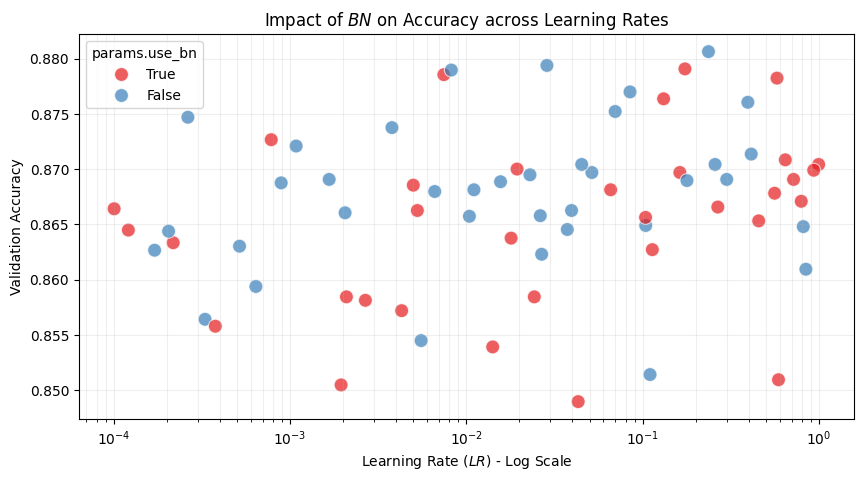

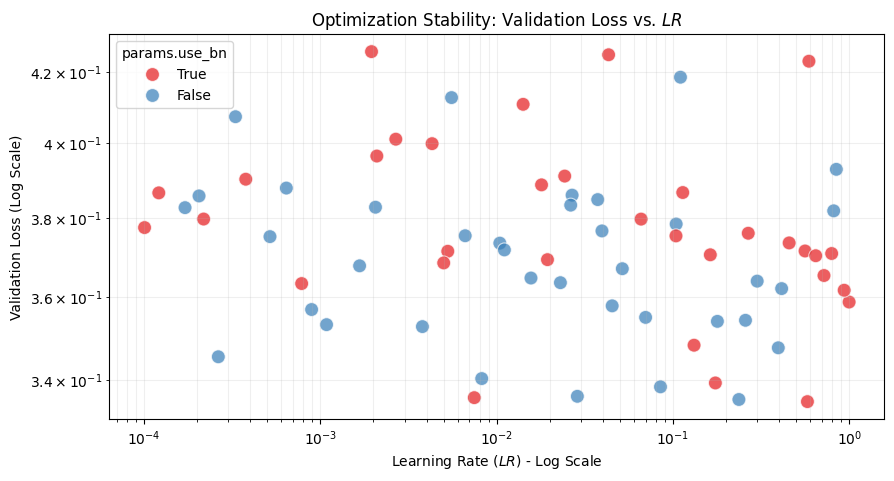

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Pre-processing: Convert MLflow strings to numeric types
df['params.lr'] = pd.to_numeric(df['params.lr'])
df['metrics.metric/Accuracy'] = pd.to_numeric(df['metrics.metric/Accuracy'])
df['metrics.Loss/test'] = pd.to_numeric(df['metrics.Loss/test'])
df['params.use_bn'] = df['params.use_bn'].astype(str)

# --- PLOT 1: ACCURACY ---
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="params.lr", 
    y="metrics.metric/Accuracy", 
    hue="params.use_bn",
    palette="Set1", s=100, alpha=0.7
)
plt.xscale('log')
plt.title("Impact of $BN$ on Accuracy across Learning Rates")
plt.xlabel("Learning Rate ($LR$) - Log Scale")
plt.ylabel("Validation Accuracy")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("accuracy_plot.png")

# --- PLOT 2: VALIDATION LOSS ---
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="params.lr", 
    y="metrics.Loss/test", 
    hue="params.use_bn",
    palette="Set1", s=100, alpha=0.7
)
plt.xscale('log')
plt.yscale('log') # Loss can span orders of magnitude during divergence
plt.title("Optimization Stability: Validation Loss vs. $LR$")
plt.xlabel("Learning Rate ($LR$) - Log Scale")
plt.ylabel("Validation Loss (Log Scale)")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("loss_plot.png")

In [ ]:
def objective_SGD(params):
    # Start a new MLflow run for tracking the experiment
    with mlflow.start_run():
        # Set MLflow tags to record metadata about the model and developer
        mlflow.set_tag("model", "convnet")
        mlflow.set_tag("dev", "steven")
        mlflow.set_tag("mlflow.runName", f"Filters-{params['conv_channels']}-fc{params['fully_connected_dim']}")
        # Log hyperparameters to MLflow
        mlflow.log_params(params)
        mlflow.log_param("batchsize", f"{batchsize}")

        dummy_input = torch.randn(1, 1, 28, 28).to(device)
    
        optimizer = optim.SGD
        loss_fn = torch.nn.CrossEntropyLoss()

        model = FashionDynamicModel(
            dummy_input=dummy_input,
            conv_channels=params["conv_channels"],
            fully_connected_dim=params["fully_connected_dim"]
        )

        # Create unique settings for this run to avoid conflicts
        run_settings = TrainerSettings(
            epochs=50,
            metrics=[accuracy],
            logdir=modeldir / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
            train_steps=100,
            valid_steps=100,    
            reporttypes=[ReportTypes.MLFLOW, ReportTypes.TOML],
            earlystop_kwargs={
                "save": True,       # Set to True to retrieve the best model
                "patience": 5,      # Stop after 5 epochs of no improvement
                "verbose": True
            },
            scheduler_kwargs={
                "factor": 0.1,
                "patience": 2}

        )

        trainer = Trainer(
            model=model,
            settings=run_settings,
            loss_fn=loss_fn,
            optimizer=optimizer,
            traindataloader=trainstreamer,
            validdataloader=validstreamer,
            scheduler=optim.lr_scheduler.ReduceLROnPlateau,
            device=device
        )
        
        trainer.loop()

        # Save the trained model with a timestamp
        tag = datetime.now().strftime("%Y%m%d-%H%M")
        modelpath = modeldir / (tag + "model.pt")
        torch.save(model, modelpath)

        # Log the saved model as an artifact in MLflow
        mlflow.log_artifact(local_path=modelpath, artifact_path="pytorch_models")
        return {'loss' : trainer.test_loss, 'status': STATUS_OK}


In [102]:
search_space_2 = {
    'conv_channels': [32, 64, 128, 256],
    'fully_connected_dim': 128,
    'use_bn': hp.choice('use_bn', [True, False]),
    'lr': hp.loguniform('lr', np.log(1e-4), np.log(1.0)),
}

In [103]:
# Setting up ML Flow
experiment_path = "fashion_test_bn_3"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(experiment_path)

2026/03/01 13:24:13 INFO mlflow.tracking.fluent: Experiment with name 'fashion_test_bn_3' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/mlruns/6', creation_time=1772367853735, experiment_id='6', last_update_time=1772367853735, lifecycle_stage='active', name='fashion_test_bn_3', tags={}>

In [104]:
best_result = fmin(
    fn=objective_SGD,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

100%|##########| 100/100 [00:00<00:00, 213.38it/s]
2026-03-01 13:49:58.752 | INFO     | mltrainer.trainer:report:209 - Epoch 42 train 0.9838 test 0.9972 metric ['0.6727']
2026-03-01 13:49:58.753 | INFO     | mltrainer.trainer:save_checkpoint:268 - Validation loss (1.0143 --> 0.9972).Saving /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_134916/20260301-134916/checkpoint.pt ...
100%|##########| 100/100 [00:00<00:00, 230.48it/s]
2026-03-01 13:49:59.515 | INFO     | mltrainer.trainer:report:209 - Epoch 43 train 0.9814 test 0.9881 metric ['0.6708']
2026-03-01 13:49:59.515 | INFO     | mltrainer.trainer:save_checkpoint:268 - Validation loss (0.9972 --> 0.9881).Saving /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_134916/20260301-134916/checkpoint.pt ...
100%|##########| 100/100 [00:00<00:00, 268.65it/s]
2026-03-01 13:50:00.333 | INFO     | mltrainer.trainer:report:209 - Epoch 44 train 0.9686 test 0.9904 metric ['0.6609']
202

 78%|███████▊  | 39/50 [24:50<08:01, 43.81s/trial, best loss: 0.9179564344882966]

2026-03-01 13:50:04.738 | INFO     | __main__:__init__:61 - Model initialized and materialized on device: mps:0
2026-03-01 13:50:04.739 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_135004
2026-03-01 13:50:04.739 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_135004/20260301-135004
2026-03-01 13:50:04.740 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|##########| 100/100 [00:00<00:00, 241.91it/s]
2026-03-01 13:50:05.540 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 2.2901 test 2.2627 metric ['0.1445']
2026-03-01 13:50:05.540 | INFO     | mltrainer.trainer:save_checkpoint:268 - Validation loss (2.2627 --> 2.2627).Saving /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_1

 80%|████████  | 40/50 [25:37<07:28, 44.82s/trial, best loss: 0.9179564344882966]

2026-03-01 13:50:51.910 | INFO     | __main__:__init__:61 - Model initialized and materialized on device: mps:0
2026-03-01 13:50:51.911 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_135051
2026-03-01 13:50:51.912 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_135051/20260301-135051
2026-03-01 13:50:51.912 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|##########| 100/100 [00:00<00:00, 227.42it/s]
2026-03-01 13:50:52.738 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 2.2978 test 2.2697 metric ['0.1392']
2026-03-01 13:50:52.738 | INFO     | mltrainer.trainer:save_checkpoint:268 - Validation loss (2.2697 --> 2.2697).Saving /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_1

...

 96%|█████████▌| 48/50 [30:55<01:19, 39.92s/trial, best loss: 0.9179564344882966]

2026-03-01 13:56:09.781 | INFO     | __main__:__init__:61 - Model initialized and materialized on device: mps:0
2026-03-01 13:56:09.782 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_135609
2026-03-01 13:56:09.783 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_135609/20260301-135609
2026-03-01 13:56:09.783 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|##########| 100/100 [00:00<00:00, 213.55it/s]
2026-03-01 13:56:10.574 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 2.2905 test 2.2687 metric ['0.1509']
2026-03-01 13:56:10.574 | INFO     | mltrainer.trainer:save_checkpoint:268 - Validation loss (2.2687 --> 2.2687).Saving /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_1

 98%|█████████▊| 49/50 [31:36<00:40, 40.26s/trial, best loss: 0.9179564344882966]

2026-03-01 13:56:50.849 | INFO     | __main__:__init__:61 - Model initialized and materialized on device: mps:0
2026-03-01 13:56:50.854 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_135650
2026-03-01 13:56:50.855 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_135650/20260301-135650
2026-03-01 13:56:50.858 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|##########| 100/100 [00:00<00:00, 220.13it/s]
2026-03-01 13:56:51.678 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 2.2736 test 2.2500 metric ['0.1811']
2026-03-01 13:56:51.678 | INFO     | mltrainer.trainer:save_checkpoint:268 - Validation loss (2.2500 --> 2.2500).Saving /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_1

100%|██████████| 50/50 [32:18<00:00, 38.76s/trial, best loss: 0.9179564344882966]


In [107]:
# Fetch data from MLflow
df = mlflow.search_runs(experiment_names=["fashion_test_bn_3"])

# Show all available columns
print("=== All Columns ===")
print(runs_df.columns.tolist())

print("\n=== Parameter Columns ===")
param_cols = [col for col in runs_df.columns if col.startswith('params.')]
print(param_cols)

=== All Columns ===
['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time']

=== Parameter Columns ===
[]


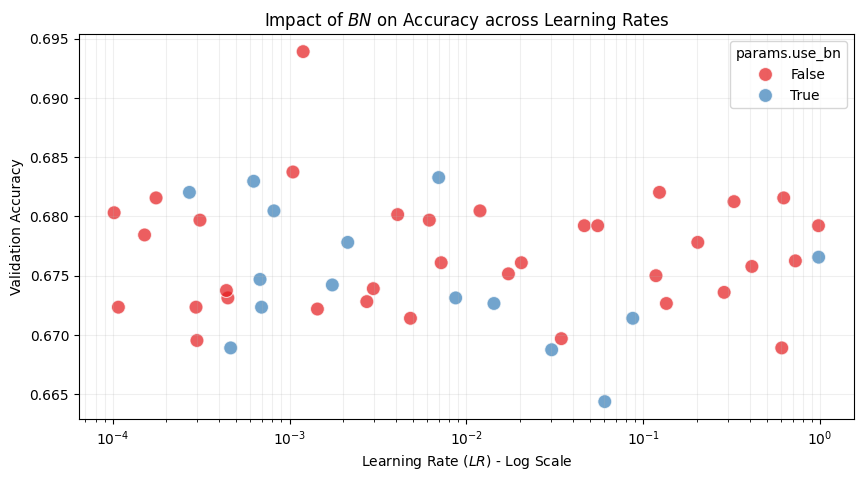

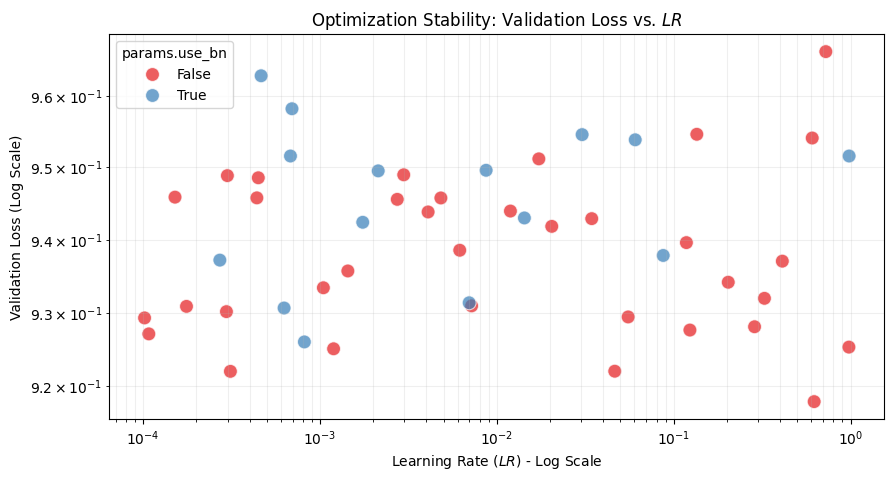

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Pre-processing: Convert MLflow strings to numeric types
df['params.lr'] = pd.to_numeric(df['params.lr'])
df['metrics.metric/Accuracy'] = pd.to_numeric(df['metrics.metric/Accuracy'])
df['metrics.Loss/test'] = pd.to_numeric(df['metrics.Loss/test'])
df['params.use_bn'] = df['params.use_bn'].astype(str)

# --- PLOT 1: ACCURACY ---
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="params.lr", 
    y="metrics.metric/Accuracy", 
    hue="params.use_bn",
    palette="Set1", s=100, alpha=0.7
)
plt.xscale('log')
plt.title("Impact of $BN$ on Accuracy across Learning Rates")
plt.xlabel("Learning Rate ($LR$) - Log Scale")
plt.ylabel("Validation Accuracy")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("accuracy_plot.png")

# --- PLOT 2: VALIDATION LOSS ---
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="params.lr", 
    y="metrics.Loss/test", 
    hue="params.use_bn",
    palette="Set1", s=100, alpha=0.7
)
plt.xscale('log')
plt.yscale('log') # Loss can span orders of magnitude during divergence
plt.title("Optimization Stability: Validation Loss vs. $LR$")
plt.xlabel("Learning Rate ($LR$) - Log Scale")
plt.ylabel("Validation Loss (Log Scale)")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("loss_plot.png")

In [130]:
def objective_SGD_no_scheduler(params):
    # Start a new MLflow run for tracking the experiment
    with mlflow.start_run():
        # Set MLflow tags to record metadata about the model and developer
        mlflow.set_tag("model", "convnet")
        mlflow.set_tag("dev", "steven")
        mlflow.set_tag("mlflow.runName", f"Filters-{params['conv_channels']}-fc{params['fully_connected_dim']}")
        # Log hyperparameters to MLflow
        mlflow.log_params(params)
        mlflow.log_param("batchsize", f"{batchsize}")

        dummy_input = torch.randn(1, 1, 28, 28).to(device)
        loss_fn = torch.nn.CrossEntropyLoss()

        model = FashionDynamicModel(
            dummy_input=dummy_input,
            conv_channels=params["conv_channels"],
            fully_connected_dim=params["fully_connected_dim"],
            use_bn=params["use_bn"]
        )

        optimizer = torch.optim.SGD

        # Create unique settings for this run to avoid conflicts
        run_settings = TrainerSettings(
            epochs=50,
            metrics=[accuracy],
            logdir=modeldir / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
            train_steps=150,
            valid_steps=150,
            reporttypes=[ReportTypes.MLFLOW, ReportTypes.TOML],
            earlystop_kwargs={
                "save": True,       # Set to True to retrieve the best model
                "patience": 5,      # Stop after 5 epochs of no improvement
                "verbose": True
            },
            optimizer_kwargs={
                "lr": params["lr"],
                "momentum": 0.9,
                "weight_decay": 1e-5
            },
            scheduler_kwargs=None

        )

        trainer = Trainer(
            model=model,
            settings=run_settings,
            loss_fn=loss_fn,
            optimizer=optimizer,
            traindataloader=trainstreamer,
            validdataloader=validstreamer,
            scheduler=None,
            device=device
        )
        
        trainer.loop()

        # Save the trained model with a timestamp
        tag = datetime.now().strftime("%Y%m%d-%H%M")
        modelpath = modeldir / (tag + "model.pt")
        torch.save(model, modelpath)

        # Log the saved model as an artifact in MLflow
        mlflow.log_artifact(local_path=modelpath, artifact_path="pytorch_models")
        return {'loss' : trainer.test_loss, 'status': STATUS_OK}


In [126]:
# Setting up ML Flow
experiment_path = "fashion_test_bn_4"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(experiment_path)

<Experiment: artifact_location='/Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/mlruns/7', creation_time=1772369904917, experiment_id='7', last_update_time=1772369904917, lifecycle_stage='active', name='fashion_test_bn_4', tags={}>

In [ ]:
best_result = fmin(
    fn=objective_SGD_no_scheduler,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

In [134]:
# Fetch data from MLflow
df = mlflow.search_runs(experiment_names=["fashion_test_bn_4"])

# Show all available columns
print("=== All Columns ===")
print(runs_df.columns.tolist())

print("\n=== Parameter Columns ===")
param_cols = [col for col in runs_df.columns if col.startswith('params.')]
print(param_cols)

=== All Columns ===
['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time']

=== Parameter Columns ===
[]


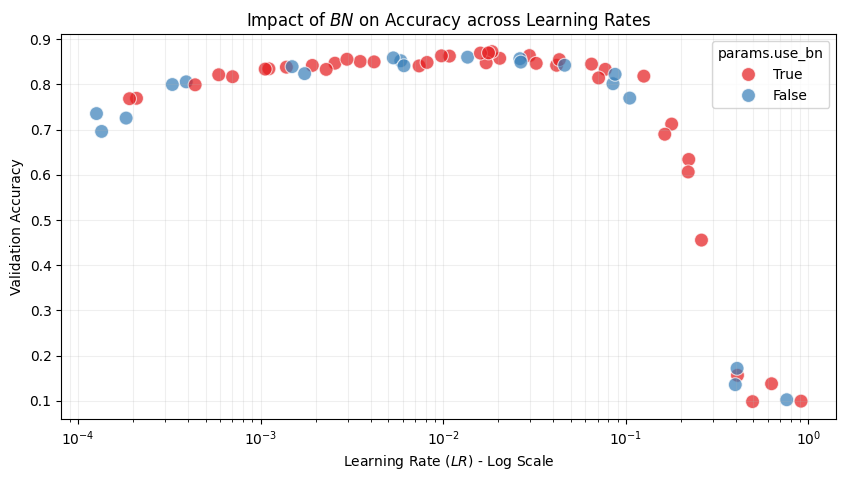

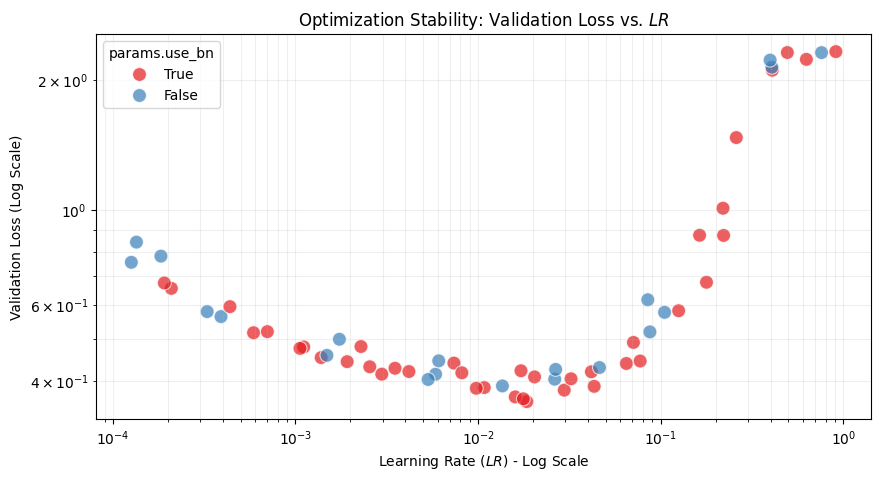

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Pre-processing: Convert MLflow strings to numeric types
df['params.lr'] = pd.to_numeric(df['params.lr'])
df['metrics.metric/Accuracy'] = pd.to_numeric(df['metrics.metric/Accuracy'])
df['metrics.Loss/test'] = pd.to_numeric(df['metrics.Loss/test'])
df['params.use_bn'] = df['params.use_bn'].astype(str)

# --- PLOT 1: ACCURACY ---
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="params.lr", 
    y="metrics.metric/Accuracy", 
    hue="params.use_bn",
    palette="Set1", s=100, alpha=0.7
)
plt.xscale('log')
plt.title("Impact of $BN$ on Accuracy across Learning Rates")
plt.xlabel("Learning Rate ($LR$) - Log Scale")
plt.ylabel("Validation Accuracy")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("accuracy_plot.png")

# --- PLOT 2: VALIDATION LOSS ---
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="params.lr", 
    y="metrics.Loss/test", 
    hue="params.use_bn",
    palette="Set1", s=100, alpha=0.7
)
plt.xscale('log')
plt.yscale('log') # Loss can span orders of magnitude during divergence
plt.title("Optimization Stability: Validation Loss vs. $LR$")
plt.xlabel("Learning Rate ($LR$) - Log Scale")
plt.ylabel("Validation Loss (Log Scale)")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("loss_plot.png")

In [143]:
def objective_SGD_no_scheduler_no_stop(params):
    # Start a new MLflow run for tracking the experiment
    with mlflow.start_run():
        # Set MLflow tags to record metadata about the model and developer
        mlflow.set_tag("model", "convnet")
        mlflow.set_tag("dev", "steven")
        mlflow.set_tag("mlflow.runName", f"Filters-{params['conv_channels']}-fc{params['fully_connected_dim']}")
        # Log hyperparameters to MLflow
        mlflow.log_params(params)
        mlflow.log_param("batchsize", f"{batchsize}")

        dummy_input = torch.randn(1, 1, 28, 28).to(device)
        loss_fn = torch.nn.CrossEntropyLoss()

        model = FashionDynamicModel(
            dummy_input=dummy_input,
            conv_channels=params["conv_channels"],
            fully_connected_dim=params["fully_connected_dim"],
            use_bn=params["use_bn"]
        )

        optimizer = torch.optim.SGD

        # Create unique settings for this run to avoid conflicts
        run_settings = TrainerSettings(
            epochs=30,
            metrics=[accuracy],
            logdir=modeldir / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
            train_steps=150,
            valid_steps=150,
            reporttypes=[ReportTypes.MLFLOW, ReportTypes.TOML],
            earlystop_kwargs=None,
            optimizer_kwargs={
                "lr": params["lr"],
                "momentum": 0.9,
                "weight_decay": 1e-5
            },
            scheduler_kwargs=None

        )

        trainer = Trainer(
            model=model,
            settings=run_settings,
            loss_fn=loss_fn,
            optimizer=optimizer,
            traindataloader=trainstreamer,
            validdataloader=validstreamer,
            scheduler=None,
            device=device
        )
        
        trainer.loop()

        # Save the trained model with a timestamp
        tag = datetime.now().strftime("%Y%m%d-%H%M")
        modelpath = modeldir / (tag + "model.pt")
        torch.save(model, modelpath)

        # Log the saved model as an artifact in MLflow
        mlflow.log_artifact(local_path=modelpath, artifact_path="pytorch_models")
        return {'loss' : trainer.test_loss, 'status': STATUS_OK}


In [140]:
# Setting up ML Flow
experiment_path = "fashion_test_bn_final"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(experiment_path)

<Experiment: artifact_location='/Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/mlruns/8', creation_time=1772376389195, experiment_id='8', last_update_time=1772376389195, lifecycle_stage='active', name='fashion_test_bn_final', tags={}>

In [144]:
search_space_3 = {
    'conv_channels': [32, 64, 128, 256],
    'fully_connected_dim': 128,
    'use_bn': hp.choice('use_bn', [True, False]),
    'lr': hp.loguniform('lr', np.log(1e-4), np.log(1.0)),
}

In [ ]:
best_result = fmin(
    fn=objective_SGD_no_scheduler_no_stop,
    space=search_space_3,
    algo=tpe.suggest,
    max_evals=20,§
    trials=Trials()
)

In [146]:
# Fetch data from MLflow
df = mlflow.search_runs(experiment_names=["fashion_test_bn_final"])

# Show all available columns
print("=== All Columns ===")
print(runs_df.columns.tolist())

print("\n=== Parameter Columns ===")
param_cols = [col for col in runs_df.columns if col.startswith('params.')]
print(param_cols)

=== All Columns ===
['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time']

=== Parameter Columns ===
[]


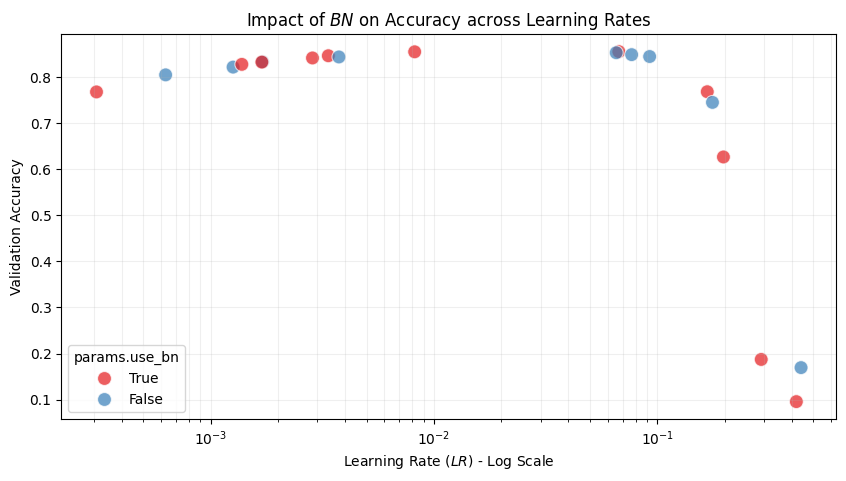

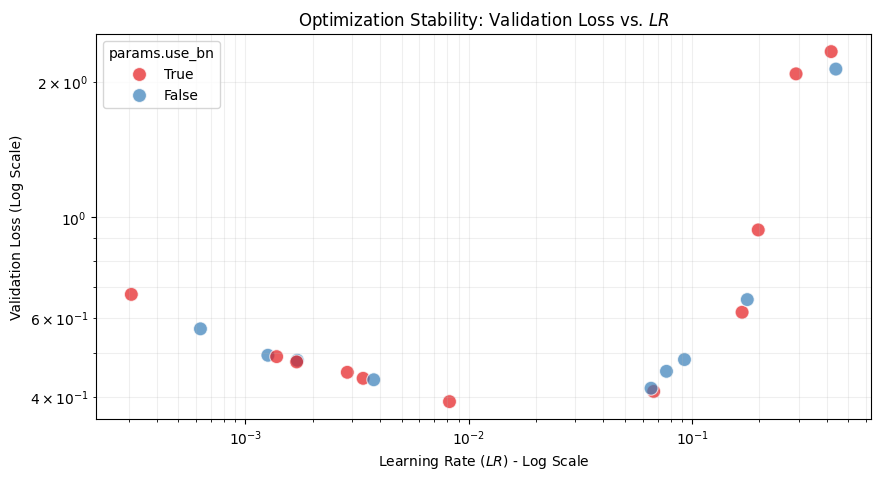

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Pre-processing: Convert MLflow strings to numeric types
df['params.lr'] = pd.to_numeric(df['params.lr'])
df['metrics.metric/Accuracy'] = pd.to_numeric(df['metrics.metric/Accuracy'])
df['metrics.Loss/test'] = pd.to_numeric(df['metrics.Loss/test'])
df['params.use_bn'] = df['params.use_bn'].astype(str)

# --- PLOT 1: ACCURACY ---
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="params.lr", 
    y="metrics.metric/Accuracy", 
    hue="params.use_bn",
    palette="Set1", s=100, alpha=0.7
)
plt.xscale('log')
plt.title("Impact of $BN$ on Accuracy across Learning Rates")
plt.xlabel("Learning Rate ($LR$) - Log Scale")
plt.ylabel("Validation Accuracy")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("accuracy_plot.png")

# --- PLOT 2: VALIDATION LOSS ---
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="params.lr", 
    y="metrics.Loss/test", 
    hue="params.use_bn",
    palette="Set1", s=100, alpha=0.7
)
plt.xscale('log')
plt.yscale('log') # Loss can span orders of magnitude during divergence
plt.title("Optimization Stability: Validation Loss vs. $LR$")
plt.xlabel("Learning Rate ($LR$) - Log Scale")
plt.ylabel("Validation Loss (Log Scale)")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("loss_plot.png")

In [149]:
# Setting up ML Flow
experiment_path = "fashion_test_bn_no_tpe"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(experiment_path)

lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0]
bn_options = [True, False]

for lr in lrs:
    for use_bn in bn_options:
        objective_SGD_no_scheduler_no_stop({
            'lr': lr,
            'use_bn': use_bn,
            'conv_channels': [32, 64, 128, 256],
            'fully_connected_dim': 128
        })

2026-03-01 16:08:14.809 | INFO     | __main__:__init__:61 - Model initialized and materialized on device: mps:0
2026-03-01 16:08:14.811 | INFO     | mltrainer.settings:check_path:60 - Created logdir /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_160814
2026-03-01 16:08:14.812 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to /Users/stevenbontius/Documents/Projects/MADS/MADS-ML-StevenB/models/run_20260301_160814/20260301-160814
100%|██████████| 150/150 [00:00<00:00, 174.42it/s]
2026-03-01 16:08:16.445 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 2.2859 test 2.2550 metric ['0.1749']
100%|██████████| 150/150 [00:00<00:00, 153.17it/s]
2026-03-01 16:08:18.457 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 2.2244 test 2.1949 metric ['0.2845']
100%|██████████| 150/150 [00:00<00:00, 152.08it/s]
2026-03-01 16:08:20.210 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 2.1640 test 2.1331 metric ['0.3430']
100%|█████

In [150]:
def plot_hypothesis_results(df: pd.DataFrame):
    """
    Generates diagnostic plots to evaluate the impact of Batch Normalization 
    on model stability across different learning rates.
    """
    # 1. Internal Data Cleaning (work on a copy to avoid SettingWithCopy warnings)
    plot_df = df.copy()
    plot_df['params.lr'] = pd.to_numeric(plot_df['params.lr'])
    plot_df['metrics.metric/Accuracy'] = pd.to_numeric(plot_df['metrics.metric/Accuracy'])
    plot_df['metrics.Loss/test'] = pd.to_numeric(plot_df['metrics.Loss/test'])
    plot_df['params.use_bn'] = plot_df['params.use_bn'].astype(str)

    # Setup the figure for two subplots (Side-by-Side is great for A4 reports)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- PLOT 1: ACCURACY (The Performance View) ---
    sns.scatterplot(
        data=plot_df, x="params.lr", y="metrics.metric/Accuracy", 
        hue="params.use_bn", palette="Set1", s=100, alpha=0.8, ax=axes[0]
    )
    axes[0].set_xscale('log')
    axes[0].set_title("Impact of BN on Accuracy")
    axes[0].set_xlabel("Learning Rate (Log Scale)")
    axes[0].set_ylabel("Validation Accuracy")
    axes[0].grid(True, which="both", ls="-", alpha=0.2)

    # --- PLOT 2: VALIDATION LOSS (The Stability View) ---
    sns.scatterplot(
        data=plot_df, x="params.lr", y="metrics.Loss/test", 
        hue="params.use_bn", palette="Set1", s=100, alpha=0.8, ax=axes[1]
    )
    axes[1].set_xscale('log')
    axes[1].set_yscale('log') # Essential for spotting numerical divergence
    axes[1].set_title("Optimization Stability: Loss vs LR")
    axes[1].set_xlabel("Learning Rate (Log Scale)")
    axes[1].set_ylabel("Validation Loss (Log Scale)")
    axes[1].grid(True, which="both", ls="-", alpha=0.2)

    plt.tight_layout()
    plt.show()
    
    # Save the combined figure for your report
    fig.savefig("bn_hypothesis_test_combined.png", dpi=300)
    print("Combined plot saved as 'bn_hypothesis_test_combined.png'")

# Usage:
# plot_hypothesis_results(df)

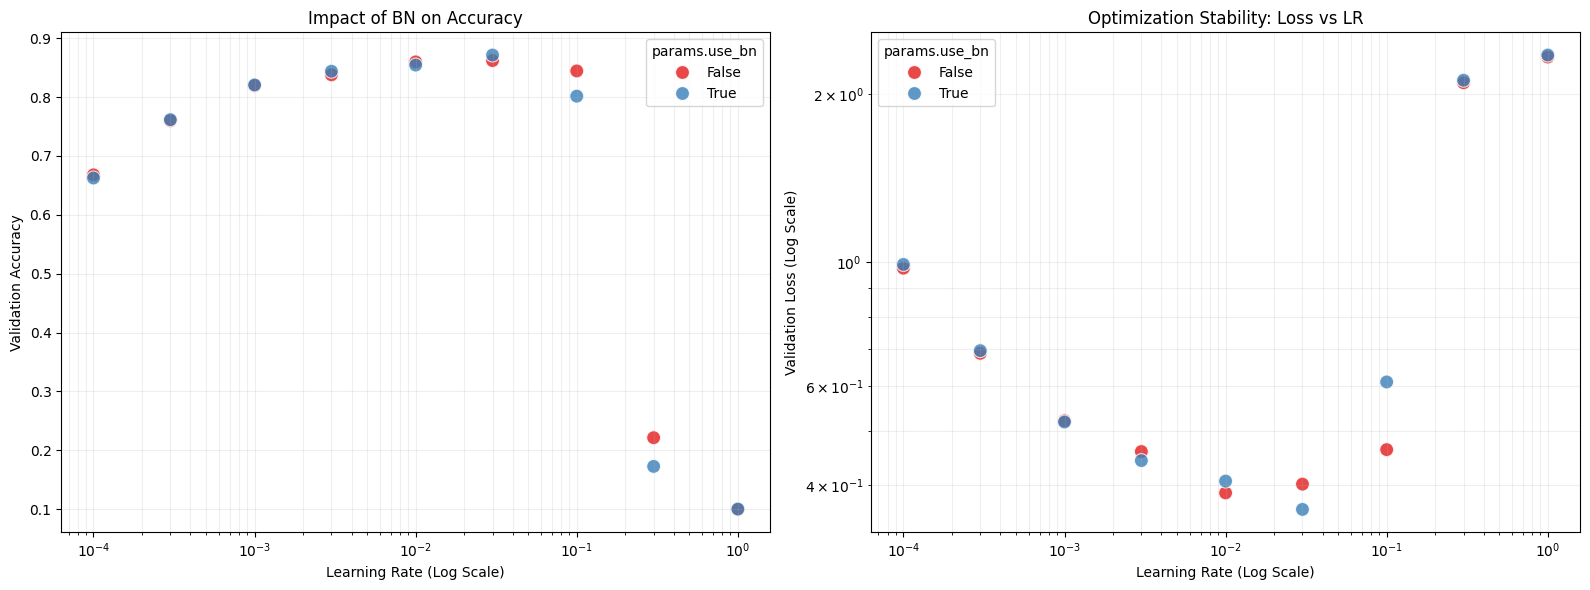

Combined plot saved as 'bn_hypothesis_test_combined.png'


In [152]:
df = mlflow.search_runs(experiment_names=["fashion_test_bn_no_tpe"])

plot_hypothesis_results(df)